In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)


S = 1601, T = 2704
Posterior draws M = 1000


Predictive Moran's I: 100%|██████████| 1000/1000 [28:45<00:00,  1.73s/it]


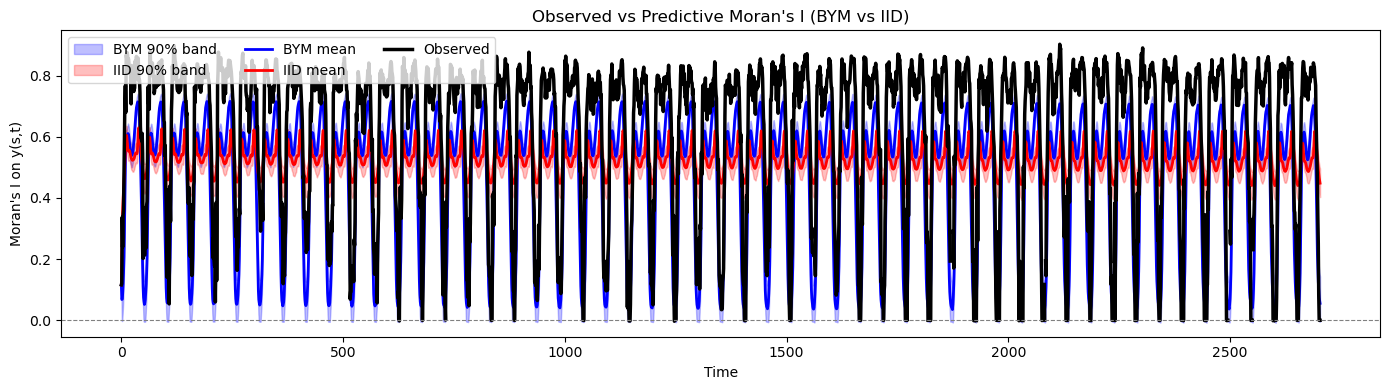

In [30]:
import numpy as np
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from pathlib import Path
from tqdm import tqdm
import pyreadr
import matplotlib.pyplot as plt

# ================================================================
# 0. CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")
period = 52

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

ALPHA_LO = 0.05   # 90% band
ALPHA_HI = 0.95

# ================================================================
# 1. LOAD DATA
# ================================================================

snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)

keep_idx = np.setdiff1d(np.arange(snow.shape[0]), no_nbs)

coords = snow.iloc[keep_idx, :2].to_numpy()
y_obs = snow.iloc[keep_idx, 2:].to_numpy()   # (S, T)

S, T = y_obs.shape
print(f"S = {S}, T = {T}")

# ================================================================
# 2. BUILD RAW ADJACENCY MATRIX W
# ================================================================

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords[:, 0], coords[:, 1]),
    crs="EPSG:4326"
)
gdf = gdf.to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")
xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

Dmat = squareform(pdist(xy))
W = (Dmat <= 0.22).astype(float)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

# ================================================================
# 3. MORAN'S I ON y (TEXTBOOK, RAW W)
# ================================================================

def morans_I_y(x, W):
    x = x.astype(float)
    x = x - x.mean()
    den = np.dot(x, x)
    if den == 0:
        return np.nan
    return (len(x) / W.sum()) * (x @ (W @ x)) / den

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ================================================================
# 4. OBSERVED MORAN'S I
# ================================================================

I_obs = np.zeros(T)
for t in range(T):
    I_obs[t] = morans_I_y(y_obs[:, t], W)

# ================================================================
# 5. LOAD POSTERIOR SAMPLES
# ================================================================

bym01 = np.load(BASE_DIR / "bym01_noIso_final.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10_noIso_final.npz")["all_theta"]

iid01 = np.load(BASE_DIR / "ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR / "ind10.npz")["all_theta"]

M = bym01.shape[1]
print(f"Posterior draws M = {M}")

# ================================================================
# 6. TIME COVARIATES
# ================================================================

t_raw = np.arange(1, T + 1)
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov_bym = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw / period), np.cos(2*np.pi*t_raw / period),
    np.sin(2*np.pi*t_raw / period), np.sin(2*np.pi*t_raw / period),
    t_trend, t_trend
])

cov_iid = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw / period),
    np.sin(2*np.pi*t_raw / period),
    t_trend
])

K_bym = cov_bym.shape[1]
K_iid = cov_iid.shape[1]

# ================================================================
# 7. PREDICTIVE MORAN'S I (BYM vs IID)
# ================================================================

I_bym = np.zeros((T, M))
I_iid = np.zeros((T, M))

for m in tqdm(range(M), desc="Predictive Moran's I"):

    # ---------- BYM ----------
    eta01_b = np.zeros((S, T))
    eta10_b = np.zeros((S, T))

    for t in range(T):
        for k in range(K_bym):
            eta01_b[:, t] += cov_bym[t, k] * bym01[k*S:(k+1)*S, m]
            eta10_b[:, t] += cov_bym[t, k] * bym10[k*S:(k+1)*S, m]

    p01_b = sigmoid(eta01_b)
    p10_b = sigmoid(eta10_b)

    p_state_b = np.zeros((S, T))
    p_state_b[:, 0] = y_obs[:, 0]

    for t in range(1, T):
        p_state_b[:, t] = (
            p_state_b[:, t-1] * (1 - p10_b[:, t]) +
            (1 - p_state_b[:, t-1]) * p01_b[:, t]
        )

    y_pred_b = np.random.binomial(1, p_state_b)

    for t in range(T):
        I_bym[t, m] = morans_I_y(y_pred_b[:, t], W)

    # ---------- IID ----------
    eta01_i = np.zeros((S, T))
    eta10_i = np.zeros((S, T))

    for t in range(T):
        for k in range(K_iid):
            eta01_i[:, t] += cov_iid[t, k] * iid01[k*S:(k+1)*S, m]
            eta10_i[:, t] += cov_iid[t, k] * iid10[k*S:(k+1)*S, m]

    p01_i = sigmoid(eta01_i)
    p10_i = sigmoid(eta10_i)

    p_state_i = np.zeros((S, T))
    p_state_i[:, 0] = y_obs[:, 0]

    for t in range(1, T):
        p_state_i[:, t] = (
            p_state_i[:, t-1] * (1 - p10_i[:, t]) +
            (1 - p_state_i[:, t-1]) * p01_i[:, t]
        )

    y_pred_i = np.random.binomial(1, p_state_i)

    for t in range(T):
        I_iid[t, m] = morans_I_y(y_pred_i[:, t], W)

# ================================================================
# 8. SUMMARY STATISTICS
# ================================================================

I_bym_mean = np.nanmean(I_bym, axis=1)
I_iid_mean = np.nanmean(I_iid, axis=1)

I_bym_lo = np.nanquantile(I_bym, ALPHA_LO, axis=1)
I_bym_hi = np.nanquantile(I_bym, ALPHA_HI, axis=1)

I_iid_lo = np.nanquantile(I_iid, ALPHA_LO, axis=1)
I_iid_hi = np.nanquantile(I_iid, ALPHA_HI, axis=1)

# ================================================================
# 9. SAVE
# ================================================================

np.savez_compressed(
    BASE_DIR / "moran_y_obs_bym_iid_with_uncertainty.npz",
    I_obs=I_obs,
    I_bym=I_bym,
    I_iid=I_iid
)

# ================================================================
# 10. PLOT
# ================================================================

t_plot = np.arange(T)

plt.figure(figsize=(14,4))

# uncertainty bands
plt.fill_between(t_plot, I_bym_lo, I_bym_hi,
                 color="blue", alpha=0.25, label="BYM 90% band")
plt.fill_between(t_plot, I_iid_lo, I_iid_hi,
                 color="red", alpha=0.25, label="IID 90% band")

# posterior means
plt.plot(t_plot, I_bym_mean, color="blue", linewidth=2, label="BYM mean")
plt.plot(t_plot, I_iid_mean, color="red", linewidth=2, label="IID mean")

# observed
plt.plot(t_plot, I_obs, color="black", linewidth=2.5, label="Observed")

plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Moran's I on y(s,t)")
plt.title("Observed vs Predictive Moran's I (BYM vs IID)")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


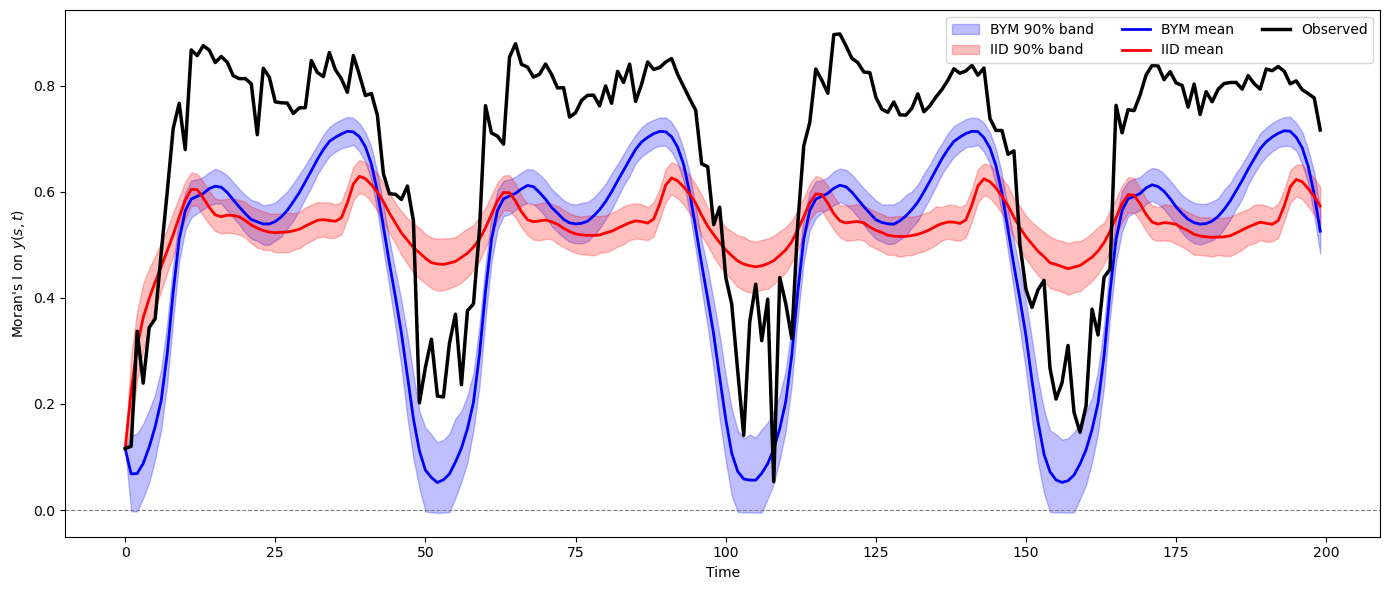

In [33]:
T_show = 200
t_plot = np.arange(T_show)

plt.figure(figsize=(14,6))

# uncertainty bands
plt.fill_between(
    t_plot,
    I_bym_lo[:T_show],
    I_bym_hi[:T_show],
    color="blue", alpha=0.25, label="BYM 90% band"
)
plt.fill_between(
    t_plot,
    I_iid_lo[:T_show],
    I_iid_hi[:T_show],
    color="red", alpha=0.25, label="IID 90% band"
)

# posterior means
plt.plot(t_plot, I_bym_mean[:T_show],
         color="blue", linewidth=2, label="BYM mean")
plt.plot(t_plot, I_iid_mean[:T_show],
         color="red", linewidth=2, label="IID mean")

# observed
plt.plot(t_plot, I_obs[:T_show],
         color="black", linewidth=2.5, label="Observed")

plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Moran's I on $y(s,t)$")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()
